In [1]:
import cv2
import matplotlib.pyplot as plt
%matplotlib inline

# Helper functions to read and display image

In [2]:
def imread_rgb(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

def imshow(img, figsize=(5, 5)):
    plt.figure(figsize=figsize)
    plt.imshow(img, cmap='gray')
    plt.show()

# Example 1: Shapes image

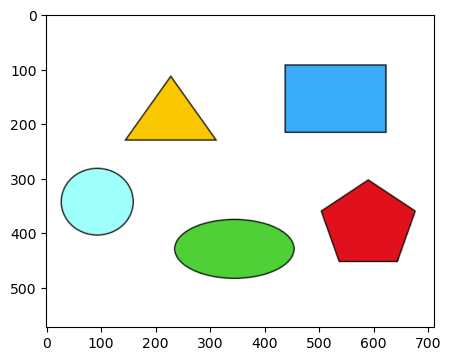

In [3]:
img_shapes = imread_rgb('images/shapes.png')
imshow(img_shapes)

### Converting image to gray

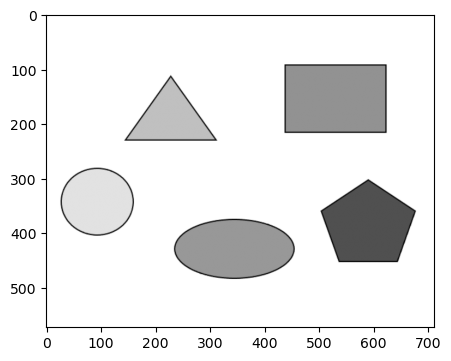

In [4]:
img_shapes_gray = cv2.cvtColor(img_shapes, cv2.COLOR_RGB2GRAY)
imshow(img_shapes_gray)

### Thresholding (converting to binary)

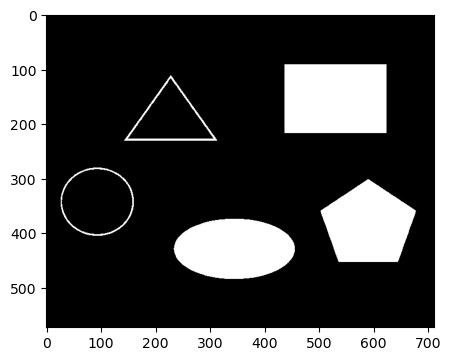

In [5]:
t, img_shapes_bin = cv2.threshold(
    img_shapes_gray, 
    0, 
    255, 
    cv2.THRESH_OTSU|cv2.THRESH_BINARY_INV
)

imshow(img_shapes_bin)

### Detecting connected components

We use `cv2.connectedComponentsWithStats` function which takes the binary image and the connectivity (4 or 8) as input. The function returns 4 outputs: 
- nLabels: The number of connected components found in the image (plus the background)
- labels: A map with the same size as the image that shows the location of pixels of each component. The value at each pixel is the index of the component (0 for background, 1 for first component, 2 for second component, etc.)
- stats: A 2D array where each row represents the stats of a component (x, y, width, height, and area). The first row (index 0) is for background.
- centroids: A 2D array where each row contains the (x-center, y-center) of a component (row index 0 is for background).

**Note**: The centroids are float by default, we convert them to int if we want to draw them.

In [6]:
nLabels, labels, stats, centroids = cv2.connectedComponentsWithStats(
    img_shapes_bin, connectivity=4)

In [10]:
nLabels

6

In [11]:
labels

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(573, 711), dtype=int32)

In [12]:
stats

array([[     0,      0,    711,    573, 343254],
       [   437,     92,    187,    126,  23562],
       [   143,    112,    171,    120,   1652],
       [    27,    281,    134,    125,   1219],
       [   503,    302,    175,    152,  18456],
       [   234,    375,    222,    110,  19260]], dtype=int32)

In [13]:
centroids

array([[332.45980819, 281.85437897],
       [530.        , 154.5       ],
       [228.23789346, 194.84443099],
       [ 94.41755537, 343.74979491],
       [590.05808409, 385.602785  ],
       [344.7450675 , 429.47492212]])

In [9]:
mask = (labels == 1)
mask

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]], shape=(573, 711))

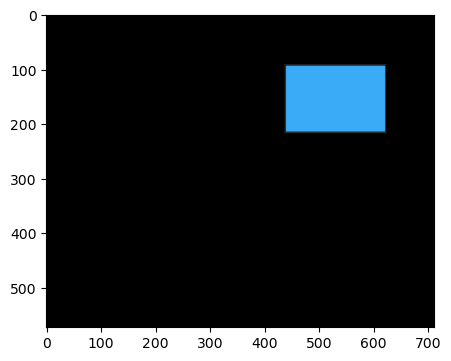

In [7]:
mask = (labels == 1).astype('uint8')
img2 = cv2.bitwise_and(img_shapes, img_shapes, mask=mask)
imshow(img2)

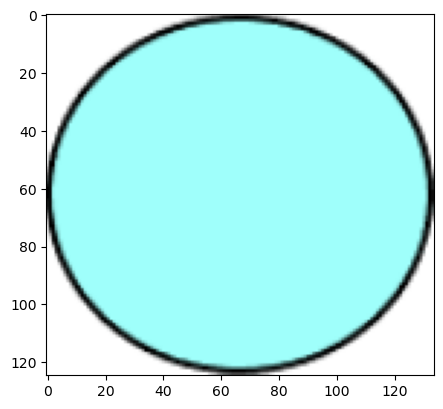

In [17]:
x, y, w, h, area = stats[3]

img2 = img_shapes[y:y+h, x:x+w]

imshow(img2)

In [15]:
components = cv2.connectedComponentsWithStats(
    img_shapes_bin, connectivity=4)

(nLabels, labels, stats, centroids) = components

centroids = centroids.astype(int)

In the following code, we loop through components by using `for i in range(1, nLabels)`. We start from 1 (not 0) because we want to skip the background. 

At each iteration, we get the values of `x`, `y`, `w`, `h`, `area`, `cx`, and `cy` of each component. 

We use `x`, `y`, `w`, and `h` to draw a box (rectangle) around the component, and we use `cx` and `cy` to draw a small circle at the center.

**To draw a rectangle**: We use `cv2.rectangle` to draw a rectangle on the given image. 
- 1st parmeter: The image
- 2nd parameter: Upper left point (x1, y1)
- 3rd parameter: Lower right point (x2, y2)
- 4th parameter: Color of rectangle as 3 values: (red, green, blue)
- 5th parameter: line thickness of rectangle (use a negative if you want to fill the rectangle)

**To draw a circle**: We use `cv2.circle` to draw a circle on the given image. 
- 1st parmeter: The image
- 2nd parameter: center point of the circle (x, y)
- 3rd parameter: radius
- 4th parameter: Color of circle as 3 values: (red, green, blue)
- 5th parameter: line thickness of circle (use a negative if you want to fill the circle)

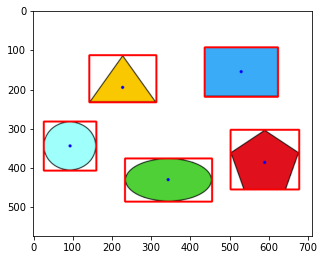

In [177]:
# copy image to avoid drawing on the original image
img = img_shapes.copy()

for i in range(1, nLabels):
    x, y, w, h, area = stats[i]
    (cx, cy) = centroids[i]   
    cv2.rectangle(img, (x, y), (x+w, y+h), (255, 0,0), 3)
    cv2.circle(img, (cx, cy), 4, (0, 0, 255), -1)

# show image with locations of detected components
imshow(img)

# Example 2: Car plate numbers
Assume we want to detect the numbers and letters on the car plate

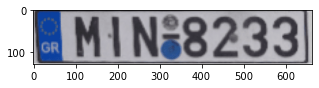

In [178]:
img_plate = imread_rgb('images/car-plate.png')
imshow(img_plate)

### Converting image to gray, then to binary

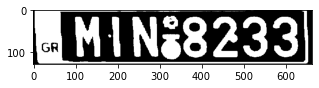

In [179]:
img_plate_gray = cv2.cvtColor(img_plate, cv2.COLOR_RGB2GRAY)

t, img_plate_bin = cv2.threshold(
    img_plate_gray, 
    0, 
    255, 
    cv2.THRESH_OTSU|cv2.THRESH_BINARY_INV
)

imshow(img_plate_bin)

### Detecting and showing connected components

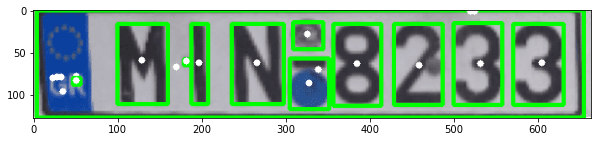

In [180]:
# detect connected components
components = cv2.connectedComponentsWithStats(
    img_plate_bin, connectivity=4)
(nLabels, labels, stats, centroids) = components
centroids = centroids.astype(int)

# copy image to avoid drawing on the original image
img = img_plate.copy()

for i in range(1, nLabels):
    x, y, w, h, area = stats[i]
    (cx, cy) = centroids[i]   
    cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 3)
    cv2.circle(img, (cx, cy), 4, (255, 255, 255), -1)

# show image with locations of detected components
imshow(img, figsize=(10, 10))

In the previous image, we notice that there are noisy/unnecessary parts detected. We can filter them by using the value of width, height, and area of the detected component. Try playing with different values for minimum or maximum width/height and see the difference.

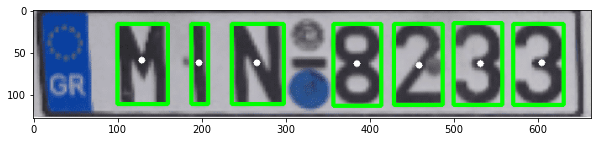

In [181]:
# detect connected components
components = cv2.connectedComponentsWithStats(
    img_plate_bin, connectivity=4)
(nLabels, labels, stats, centroids) = components
centroids = centroids.astype(int)

# copy image to avoid drawing on the original image
img = img_plate.copy()

for i in range(1, nLabels):
    x, y, w, h, area = stats[i]
    (cx, cy) = centroids[i]   
    
    # check the width and height are within a defined range
    # you can try different values and see the result
    acceptWidth = (w > 10 and w < 100)
    acceptHeight = (h > 90 and h < 120)
    
    if acceptWidth and acceptHeight:
        cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 3)
        cv2.circle(img, (cx, cy), 4, (255, 255, 255), -1)

# show image with locations of detected components
imshow(img, figsize=(10, 10))

# We can put the previous code together in a helper function
We define a function that takes the RGB image as input. It also takes 3 optional parameters:
- w_range: The accepted width range for components (min, max)
- h_range: The accepted height range for components (min, max)

The function doesn't return anything, but it draws the locations of the detected components

In [182]:
def detect_connected_components(
        img_rgb, 
        w_range=None, 
        h_range=None,
):
    # convert image to gray
    img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

    # convert gray image to binary
    t, img_bin = cv2.threshold(
        img_gray, 
        0, 
        255, 
        cv2.THRESH_OTSU|cv2.THRESH_BINARY_INV
    )

    # detect connected components
    components = cv2.connectedComponentsWithStats(
        img_bin, connectivity=4)
    (nLabels, labels, stats, centroids) = components
    centroids = centroids.astype(int)

    # copy image to avoid drawing on the original image
    img = img_rgb.copy()

    # loop through components
    for i in range(1, nLabels):
        x, y, w, h, area = stats[i]
        (cx, cy) = centroids[i]   

        # by default, there is no limit for width or height
        acceptWidth = True
        acceptHeight = True
        
        # check the width, and height are within range (if defined)
        if w_range:
            acceptWidth = (w > w_range[0] and w < w_range[1])
        if h_range:
            acceptHeight = (h > h_range[0] and h < h_range[1])
        
        # draw location if width and height are accepted
        if acceptWidth and acceptHeight:
            cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 3)
            cv2.circle(img, (cx, cy), 4, (255, 255, 255), -1)

    # show image with locations of detected components
    imshow(img, figsize=(10, 10))

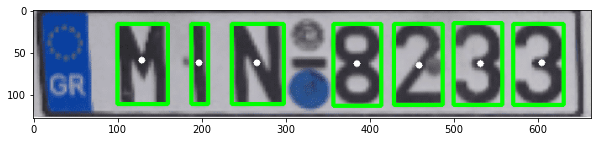

In [183]:
# Test our function
detect_connected_components(
    img_plate, 
    w_range=(10, 100), 
    h_range=(90, 120)
)

# Example 3: Sudoku

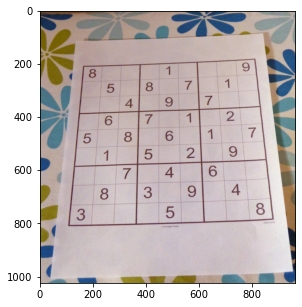

In [184]:
img_sudoku = imread_rgb('images/sudoku.jpg')
imshow(img_sudoku)

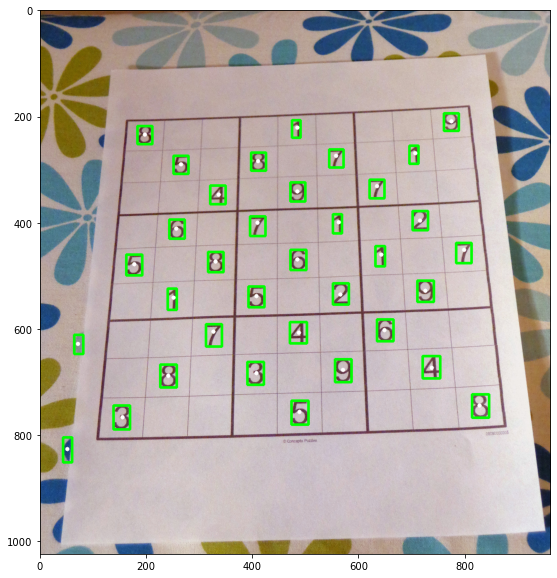

In [185]:
detect_connected_components(
    img_sudoku, 
    w_range=(15, 50), 
    h_range=(20, 50),
)

In the previous image we notice that some shapes on the background outside the paper are detected as connected components. To solve this problem we will need to use some method to remove the background and keep only the paper or the grid.